In [9]:
from random import *
import copy
import statistics
import math
import matplotlib.pyplot as plt
import random

# Set random seed for reproducible results
random.seed(42)


In [10]:

# ============================================================
# PART 1: KAUFFMAN NETWORK BASICS
# ============================================================

# Boolean functions (16 possible functions for 2 inputs)
def f0(val1,val2):
    return 0

def f1(val1,val2):
    return val1 

def f2(val1,val2):
    return 1-val1 

def f3(val1,val2):
    return val2 

def f4(val1,val2):
    return 1-val2 

def f5(val1,val2):
    if val1+val2 == 0:
        return 0
    else:
        return 1

def f6(val1,val2):
    if val1+val2 == 0:
        return 1
    else:
        return 0

def f7(val1,val2):
    if val1+val2 == 1:
        return 0
    else:
        return 1

def f8(val1,val2):
    if val1+val2 == 1:
        return 1
    else:
        return 0

def f9(val1,val2):
    if val1+val2 == 2:
        return 0
    else:
        return 1

def f10(val1, val2):
    if val1+val2 == 2:
        return 1
    else:
        return 0

def f11(val1, val2):
    if val1>val2:
        return 1
    else: 
        return 0

def f12(val1, val2):
    if val1>val2:
        return 0
    else: 
        return 1

def f13(val1, val2):
    if val2>val1:
        return 1
    else: 
        return 0

def f14(val1, val2):
    if val2>val1:
        return 0
    else: 
        return 1

def f15(val1, val2):
    return 1

def boolEval(type, val1, val2):
    functions = {0: f0, 1: f1, 2: f2, 3: f3, 4: f4, 5: f5, 6: f6, 7: f7,
                 8: f8, 9: f9, 10: f10, 11: f11, 12: f12, 13: f13, 14: f14, 15: f15}
    f = functions[type]
    return f(val1,val2)

# Node class - represents one gene
class node:
    def __init__(self):
        self.type = 0 
        self.neigh1 = None
        self.neigh2 = None
        self.value = choice([0,1])           
        self.oldvalue = self.value

    def setNeigh1(self,aNeigh):
        self.neigh1 = aNeigh

    def setNeigh2(self, aNeigh):
        self.neigh2 = aNeigh

    def evolveValue(self):
        self.value = boolEval(self.type,self.neigh1.oldvalue,self.neigh2.oldvalue)

    def getValue(self):
        return self.value

# Network class - represents the whole gene network
class net:
    def __init__(self, size):
        self.size = size
        self.nodes = []
        for i in range(0,size): 
            self.nodes.append(node())
        for i in range(0,size): 
            self.nodes[i].setNeigh1(self.nodes[randrange(0,size)])
        for i in range(0,size): 
            self.nodes[i].setNeigh2(self.nodes[randrange(0,size)])
        for i in range(0,size):
            self.nodes[i].type = randrange(0,16)

    def evolveNet(self):
        for i in range(0,self.size):  
            self.nodes[i].evolveValue()
        for i in range(0,self.size):
            self.nodes[i].oldvalue = self.nodes[i].value     

    def listvalues(self):
        l = []
        for i in range(0,self.size): 
            l += [self.nodes[i].value]
        return l

def cycle2(newstate, states):
    for i in range(len(states)):
        if states[i] == newstate:
            cyclelen = len(states) - i
            leaderlen = i
            return (cyclelen, leaderlen)
    return None

def generun2(size):
    n = net(size)
    current = n.listvalues()
    states = []
    while cycle2(current, states) == None:
        n.evolveNet()
        states += [current]
        current = n.listvalues()
    states += [current]
    return cycle2(current, states), n, states


In [11]:
# ===========================================================
# PART 2: HELPER FUNCTIONS FOR SENSITIVITY ANALYSIS
# ============================================================

def normalize_cycle(cycle_states):
    """Make cycles comparable by finding smallest rotation"""
    if not cycle_states:
        return tuple()
    rotations = []
    for i in range(len(cycle_states)):
        rotated = cycle_states[i:] + cycle_states[:i]
        rotations.append(rotated)
    return tuple(min(rotations))

def extract_attractor(states, cyclelen, leaderlen):
    """Extract the repeating cycle from state sequence"""
    cycle_start = leaderlen
    attractor = states[cycle_start:]
    return normalize_cycle(attractor)

def set_initial_state(network, state_list):
    """Reset network to specific starting state"""
    for i in range(network.size):
        network.nodes[i].value = state_list[i]
        network.nodes[i].oldvalue = state_list[i]

def get_attractor_from_start(network, initial_state):
    """Helper: Run network from initial state to get its attractor"""
    set_initial_state(network, initial_state)
    current = network.listvalues()
    states = []
    result = None
    
    while result == None:
        network.evolveNet()
        states.append(current)
        current = network.listvalues()
        result = cycle2(current, states)
    
    states.append(current)
    cyclelen, leaderlen = result
    return extract_attractor(states, cyclelen, leaderlen)


In [12]:

# ============================================================
# PART 3: SENSITIVITY ANALYSIS
# ============================================================

def create_trial_network(netsize):
    """Create one network and get baseline attractor"""
    (cyclelen, leaderlen), baseline_net, states = generun2(netsize)
    baseline_attractor = extract_attractor(states, cyclelen, leaderlen)
    initial_state = states[0]
    return baseline_net, baseline_attractor, initial_state

def test_gene_mutation(baseline_net, baseline_attractor, initial_state, gene_idx):
    """Test if mutating one gene changes the attractor"""
    mutant_net = copy.deepcopy(baseline_net)
    
    original_type = mutant_net.nodes[gene_idx].type
    new_type = original_type
    while new_type == original_type:
        new_type = randrange(0, 16)
    mutant_net.nodes[gene_idx].type = new_type
    
    set_initial_state(mutant_net, initial_state)
    current = mutant_net.listvalues()
    mutant_states = []
    result = None
    
    while result == None:
        mutant_net.evolveNet()
        mutant_states.append(current)
        current = mutant_net.listvalues()
        result = cycle2(current, mutant_states)
    
    mutant_states.append(current)
    mut_cyclelen, mut_leaderlen = result
    mutant_attractor = extract_attractor(mutant_states, mut_cyclelen, mut_leaderlen)
    
    return mutant_attractor != baseline_attractor

def run_single_trial(netsize):
    """Test all genes in one network"""
    baseline_net, baseline_attractor, initial_state = create_trial_network(netsize)
    
    changes = 0
    for gene_idx in range(netsize):
        if test_gene_mutation(baseline_net, baseline_attractor, initial_state, gene_idx):
            changes += 1
    
    sensitivity_rate = (changes / netsize) * 100
    return sensitivity_rate

def collect_trial_data(netsize, num_trials):
    """Run multiple independent networks"""
    trial_rates = []
    
    for trial_num in range(num_trials):
        rate = run_single_trial(netsize)
        trial_rates.append(rate)
    
    return trial_rates

def calculate_statistics(trial_rates):
    """Calculate mean, std dev, confidence intervals"""
    mean_rate = statistics.mean(trial_rates)
    
    std_dev = 0
    if len(trial_rates) > 1:
        std_dev = statistics.stdev(trial_rates)
    
    median_rate = statistics.median(trial_rates)
    min_rate = min(trial_rates)
    max_rate = max(trial_rates)
    
    n = len(trial_rates)
    ci_lower, ci_upper = mean_rate, mean_rate
    if n > 1:
        standard_error = std_dev / math.sqrt(n)
        t_value = 1.96 if n > 10 else 2.0
        margin = t_value * standard_error
        ci_lower = mean_rate - margin
        ci_upper = mean_rate + margin
    
    t_statistic = 0
    if n > 1 and std_dev > 0:
        t_statistic = (mean_rate - 50) / (std_dev / math.sqrt(n))
    
    return {
        'mean': mean_rate,
        'std_dev': std_dev,
        'median': median_rate,
        'min': min_rate,
        'max': max_rate,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        't_statistic': t_statistic,
        'significant': abs(t_statistic) > 2.0
    }

def statistical_sensitivity_analysis(netsize, num_trials):
    """Main analysis function"""
    trial_rates = collect_trial_data(netsize, num_trials)
    stats = calculate_statistics(trial_rates)
    return trial_rates, stats

def compare_network_sizes(sizes=[10, 15, 20], trials_per_size=20):
    """Compare sensitivity across network sizes"""
    all_results = []
    all_rates = []
    
    for size in sizes:
        trial_rates, stats = statistical_sensitivity_analysis(size, trials_per_size)
        all_results.append({
            'size': size,
            'mean': stats['mean'],
            'std': stats['std_dev'],
            'ci': (stats['ci_lower'], stats['ci_upper']),
            'median': stats['median'],
            'min': stats['min'],
            'max': stats['max'],
            't_stat': stats['t_statistic']
        })
        all_rates.append(trial_rates)
    
    return all_results, all_rates

In [13]:

# ============================================================
# PART 4: CASCADE ANALYSIS
# ============================================================

def measure_cascade_effect(baseline_attractor, mutant_attractor, netsize):
    """How many genes have different values in the new attractor?"""
    if len(baseline_attractor) != len(mutant_attractor):
        return ("cycle_length_changed", len(baseline_attractor), len(mutant_attractor))
    
    genes_affected = set()
    for base_cycle, mut_cycle in zip(baseline_attractor, mutant_attractor):
        for gene_idx in range(netsize):
            if base_cycle[gene_idx] != mut_cycle[gene_idx]:
                genes_affected.add(gene_idx)
    
    return ("state_change", len(genes_affected))

def analyze_mutation_cascades(netsize=15, num_trials=5):
    """Analyze cascade effects of disruptive mutations"""
    
    cascade_data = []
    cycle_changes = 0
    state_changes = 0
    
    for trial in range(num_trials):
        baseline_net, baseline_att, init_state = create_trial_network(netsize)
        
        for gene_idx in range(netsize):
            mutant_net = copy.deepcopy(baseline_net)
            original_type = mutant_net.nodes[gene_idx].type
            new_type = original_type
            while new_type == original_type:
                new_type = randrange(0, 16)
            mutant_net.nodes[gene_idx].type = new_type
            
            mutant_att = get_attractor_from_start(mutant_net, init_state)
            
            if mutant_att != baseline_att:
                result = measure_cascade_effect(baseline_att, mutant_att, netsize)
                if result[0] == "state_change":
                    cascade_data.append(result[1])
                    state_changes += 1
                else:
                    cycle_changes += 1
    
    if cascade_data:
        numeric_cascades = cascade_data
        mean_cascade = statistics.mean(numeric_cascades)
        std_cascade = statistics.stdev(numeric_cascades) if len(numeric_cascades) > 1 else 0
        pct_network_wide = (sum(c > netsize/2 for c in numeric_cascades) / len(numeric_cascades)) * 100
        
        return {
            'mean': mean_cascade,
            'std': std_cascade,
            'min': min(numeric_cascades),
            'max': max(numeric_cascades),
            'state_changes': state_changes,
            'cycle_changes': cycle_changes,
            'pct_network_wide': pct_network_wide,
            'data': numeric_cascades
        }
    
    return None

In [14]:

# ============================================================
# PART 5: VISUALIZATION
# ============================================================

def plot_all_results(all_results, all_rates, cascade_results=None, netsize=15):
    """Create comprehensive visualization"""
    
    fig = plt.figure(figsize=(16, 10))
    
    # Plot 1: Sensitivity bar chart
    ax1 = plt.subplot(2, 2, 1)
    sizes = [r['size'] for r in all_results]
    means = [r['mean'] for r in all_results]
    ci_lowers = [r['ci'][0] for r in all_results]
    ci_uppers = [r['ci'][1] for r in all_results]
    yerr = [means[i] - ci_lowers[i] for i in range(len(means))]
    
    ax1.bar(sizes, means, yerr=yerr, capsize=8, color='steelblue', edgecolor='black')
    ax1.axhline(50, color='red', ls='--', lw=2, label='Random (50%)')
    ax1.set_xlabel('Network size (N)')
    ax1.set_ylabel('Sensitivity rate (%)')
    ax1.set_title('Figure 1: Mean Sensitivity by Network Size')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Boxplots
    ax2 = plt.subplot(2, 2, 2)
    labels = [f'N={s}' for s in sizes]
    ax2.boxplot(all_rates, labels=labels)
    ax2.axhline(50, color='red', ls='--', lw=2, label='Random (50%)')
    ax2.set_ylabel('Sensitivity rate (%)')
    ax2.set_title('Figure 2: Sensitivity Distribution by Size')
    ax2.legend()
    
    # Plot 3: Cascade histogram
    if cascade_results:
        ax3 = plt.subplot(2, 2, 3)
        ax3.hist(cascade_results['data'], bins=range(1, netsize+1), edgecolor='black', alpha=0.7, color='coral')
        ax3.axvline(cascade_results['mean'], color='red', lw=3, label=f"Mean: {cascade_results['mean']:.1f}")
        ax3.set_xlabel('Genes Affected')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Figure 3: Cascade Size Distribution')
        ax3.legend()
        
        # Plot 4: Disruption types
        ax4 = plt.subplot(2, 2, 4)
        disruption_types = [cascade_results['state_changes'], cascade_results['cycle_changes']]
        ax4.pie(disruption_types, labels=['State Changes', 'Cycle Changes'], autopct='%1.1f%%', startangle=90)
        ax4.set_title('Figure 4: Types of Disruptions')
    
    plt.tight_layout()
    plt.show()

def print_summary_table(all_results):
    """Print summary table"""
    print("\n" + "=" * 100)
    print("Table 1: Statistical Summary of Sensitivity Analysis")
    print("=" * 100)
    print(f"{'Size':<6} {'Mean(%)':<9} {'SD(%)':<8} {'Median(%)':<10} {'Min(%)':<8} {'Max(%)':<8} {'95% CI':<20} {'t-stat':<8} {'Sig?':<8}")
    print("-" * 100)
    
    for result in all_results:
        size = result['size']
        ci_str = f"[{result['ci'][0]:.1f}, {result['ci'][1]:.1f}]"
        sig = "Yes" if result['t_stat'] > 2 else "No"
        print(f"{size:<6} {result['mean']:>7.2f}   {result['std']:>6.2f}   {result['median']:>8.2f}   {result['min']:>6.2f}   {result['max']:>6.2f}   {ci_str:<20} {result['t_stat']:>6.2f}   {sig:<8}")
    
    print("=" * 100)

def print_cascade_summary(cascade_results, netsize):
    """Print cascade analysis summary"""
    print("\n" + "=" * 60)
    print("CASCADE EFFECT ANALYSIS SUMMARY")
    print("=" * 60)
    print(f"Mean cascade size: {cascade_results['mean']:.1f} ± {cascade_results['std']:.1f} genes")
    print(f"Range: {cascade_results['min']} - {cascade_results['max']} genes ({cascade_results['min']/netsize*100:.1f}% - {cascade_results['max']/netsize*100:.1f}% of network)")
    print(f"Mutations affecting >50% of network: {cascade_results['pct_network_wide']:.1f}%")
    print(f"State changes: {cascade_results['state_changes']} | Cycle changes: {cascade_results['cycle_changes']}")
    print("=" * 60)


KAUFFMAN BOOLEAN NETWORK: SENSITIVITY & CASCADE ANALYSIS

Table 1: Statistical Summary of Sensitivity Analysis
Size   Mean(%)   SD(%)    Median(%)  Min(%)   Max(%)   95% CI               t-stat   Sig?    
----------------------------------------------------------------------------------------------------
10       76.00    16.67      80.00    40.00   100.00   [68.7, 83.3]           6.98   Yes     
15       73.33    14.83      73.33    53.33   100.00   [66.8, 79.8]           7.04   Yes     
20       71.50    14.96      72.50    40.00    90.00   [64.9, 78.1]           6.43   Yes     

Running cascade analysis for N=15...

CASCADE EFFECT ANALYSIS SUMMARY
Mean cascade size: 3.6 ± 3.6 genes
Range: 1 - 14 genes (6.7% - 93.3% of network)
Mutations affecting >50% of network: 20.9%
State changes: 67 | Cycle changes: 47

Generating visualizations...


/var/folders/g_/hyc1v5f16g19px8sc706pqq00000gn/T/ipykernel_93539/1777458046.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(all_rates, labels=labels)


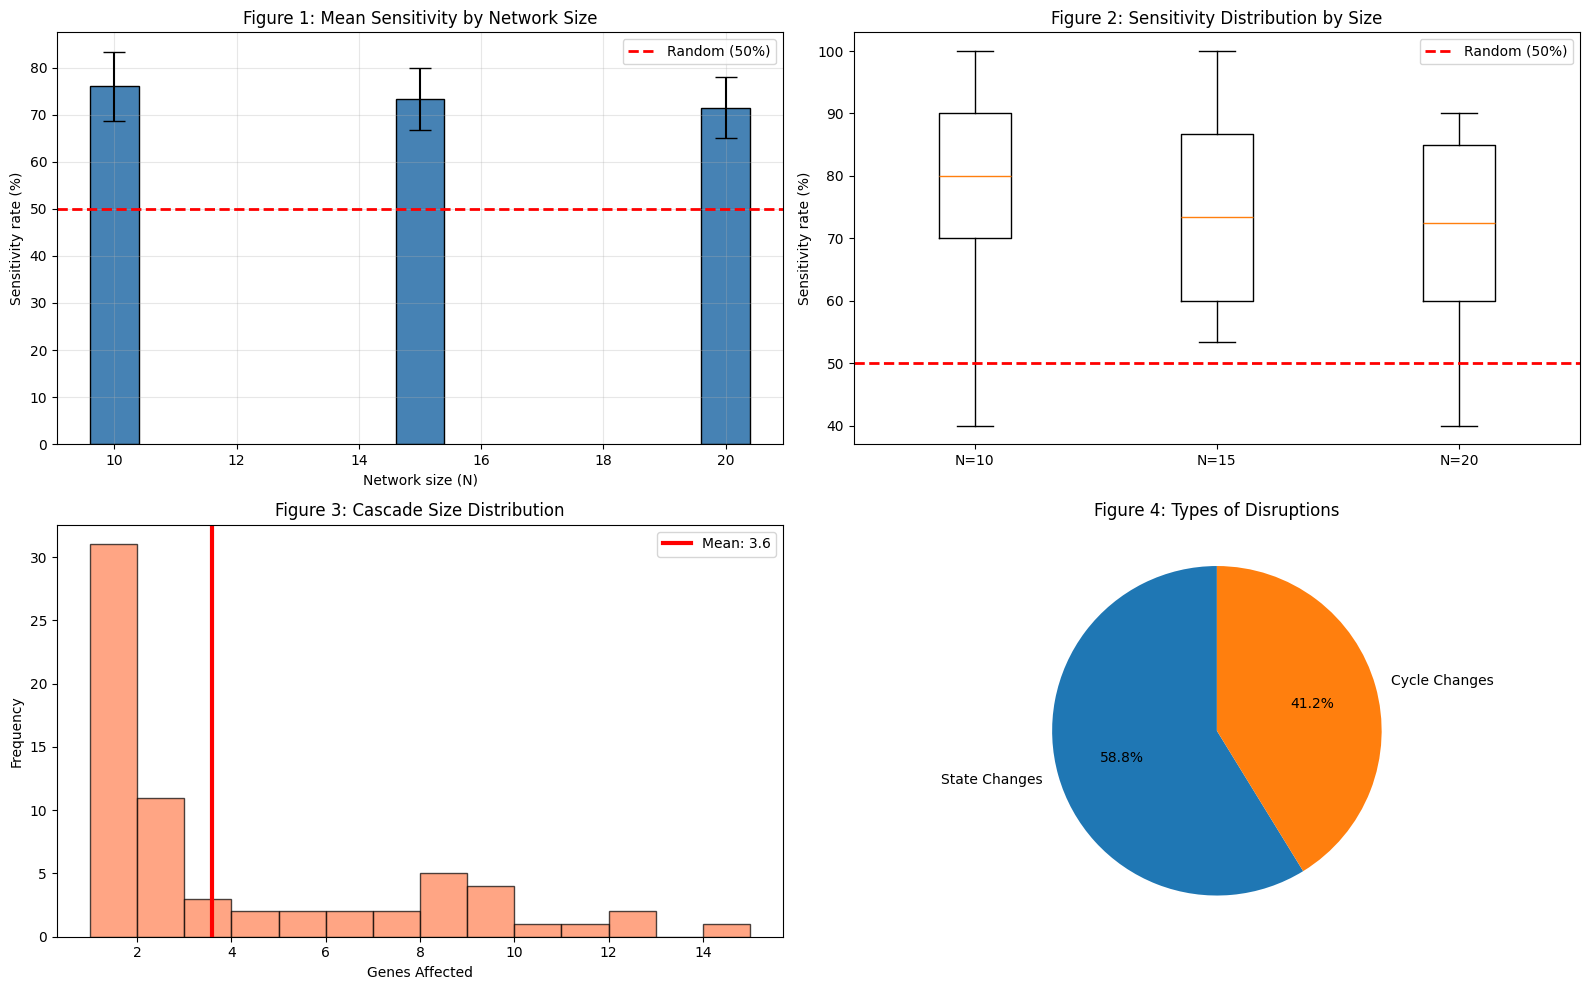

In [15]:
# ============================================================
# PART 6: MAIN EXECUTION
# ============================================================

print("\n" + "="*70)
print("KAUFFMAN BOOLEAN NETWORK: SENSITIVITY & CASCADE ANALYSIS")
print("="*70)

# Run sensitivity analysis
results, all_rates = compare_network_sizes([10, 15, 20], trials_per_size=20)

# Print summary
print_summary_table(results)

# Run cascade analysis (using N=15 from results)
print("\nRunning cascade analysis for N=15...")
cascade_results = analyze_mutation_cascades(netsize=15, num_trials=10)

if cascade_results:
    print_cascade_summary(cascade_results, 15)

# Create visualizations
print("\nGenerating visualizations...")
plot_all_results(results, all_rates, cascade_results, netsize=15)

